In [1]:
!pip install -q scanpy anndata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take

In [1]:
!pip install -q --upgrade pip

!pip install -q \
    "numpy==1.26.4" \
    "scipy==1.11.4" \
    "pandas==2.1.4" \
    "matplotlib==3.8.4" \
    "seaborn==0.13.2" \
    "anndata==0.10.8" \
    "scanpy==1.10.2" \
    "zarr<3" \
    "numba==0.59.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 17.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
spopt 0.7.0 requires scipy>=1.12.0, but you have scipy 1.11.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
esda 2.9.0 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
tobler 0.14.0 requires scipy>=1.13, but you have scipy 1.11.

In [1]:
# Load libraries
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!unzip -q "/content/Project_scRNAseq (2).zip" -d "/content/Project_scRNAseq"

In [3]:
!find "/content/Project_scRNAseq" -maxdepth 3 -type f

/content/Project_scRNAseq/Project_scRNAseq/Leukemia.zip
/content/Project_scRNAseq/Project_scRNAseq/Normal.zip
/content/Project_scRNAseq/Project_scRNAseq/sampleinfo.csv


In [4]:
# Set working directory
os.chdir("/content/Project_scRNAseq/Project_scRNAseq")

In [5]:
print(os.getcwd())
print(os.listdir())

/content/Project_scRNAseq/Project_scRNAseq
['Leukemia.zip', 'Normal.zip', 'sampleinfo.csv']


In [6]:
# Read sample information
sampleinfo = pd.read_csv("sampleinfo.csv")
sampleinfo

,SampleName,type
0,Normal,Illumina HiSeq 4000
1,Leukemia,Illumina HiSeq 4000


In [8]:
!unzip -q "Normal.zip" -d "Normal"
!unzip -q "Leukemia.zip" -d "Leukemia"

In [10]:
!find . -maxdepth 3 -type f | head -30

./Leukemia.zip
./Normal.zip
./Normal/Normal/matrix.mtx.gz
./Normal/Normal/barcodes.tsv.gz
./Normal/Normal/features.tsv.gz
./sampleinfo.csv
./Leukemia/Leukemia/matrix.mtx.gz
./Leukemia/Leukemia/barcodes.tsv.gz
./Leukemia/Leukemia/features.tsv.gz


In [11]:
# Read 10X data (per sample)

adatas = []

for sample in sampleinfo["SampleName"]:

    # Your extracted files are inside:
    # Normal/Normal/ and Leukemia/Leukemia/
    sample_path = f"{sample}/{sample}"

    adata = sc.read_10x_mtx(
        path=sample_path,
        var_names="gene_symbols",
        cache=True
    )

    # Add sample information
    adata.obs["sample"] = sample

    # Save this dataset in the list
    adatas.append(adata)

print("Successfully loaded:", sampleinfo["SampleName"].tolist())

Successfully loaded: ['Normal', 'Leukemia']


In [12]:
print(adatas)

[AnnData object with n_obs × n_vars = 760 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types', AnnData object with n_obs × n_vars = 971 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types']


In [13]:
type(adatas)

list

In [14]:
type(adata)

anndata._core.anndata.AnnData

In [15]:
# Check the shape of each AnnData object
for adata in adatas:
    sample_name = adata.obs["sample"].unique()[0]
    print(sample_name, adata.shape)


Normal (760, 36601)
Leukemia (971, 36601)


In [16]:
# Extract the AnnData object for sample RZ1
adata_leukemia = [a for a in adatas if a.obs["sample"].unique()[0] == "Leukemia"][0]
adata_leukemia[:5, :5].X


<5x5 sparse matrix of type '<class 'numpy.float32'>'
	with 0 stored elements in Compressed Sparse Column format>

In [17]:
# Convert the sparse matrix to a DataFrame
adata_leukemia[:5, :5].to_df()


,MIR1302-2HG,FAM138A,OR4F5,AL627309.1,AL627309.3
AAACCTGCAACTGCTA-1,0.0,0.0,0.0,0.0,0.0
AAACCTGGTAGGGTAC-1,0.0,0.0,0.0,0.0,0.0
AAACCTGTCATGCATG-1,0.0,0.0,0.0,0.0,0.0
AAACGGGAGGTTACCT-1,0.0,0.0,0.0,0.0,0.0
AAACGGGCAGGACCCT-1,0.0,0.0,0.0,0.0,0.0


In [18]:
# Check the first few columns (var) of the obs DataFrame for RZ1
adata_leukemia.var.head()

,gene_ids,feature_types
MIR1302-2HG,ENSG00000243485,Gene Expression
FAM138A,ENSG00000237613,Gene Expression
OR4F5,ENSG00000186092,Gene Expression
AL627309.1,ENSG00000238009,Gene Expression
AL627309.3,ENSG00000239945,Gene Expression


In [19]:
# Check the first few rows (obs) of the obs DataFrame for RZ1
adata_leukemia.obs.head()

,sample
AAACCTGCAACTGCTA-1,Leukemia
AAACCTGGTAGGGTAC-1,Leukemia
AAACCTGTCATGCATG-1,Leukemia
AAACGGGAGGTTACCT-1,Leukemia
AAACGGGCAGGACCCT-1,Leukemia


In [20]:
# Merge samples into one object
adata = ad.concat(
    adatas,
    join="outer",
    label="sample_id",
    keys=sampleinfo["SampleName"]
)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [21]:
print(adata)

AnnData object with n_obs × n_vars = 1731 × 36601
    obs: 'sample', 'sample_id'


In [22]:
adata.X.shape

(1731, 36601)

In [23]:
(adata.X > 0).sum() / (adata.n_obs * adata.n_vars)

0.07108648700001267

In [24]:
adata.X.min(), adata.X.max()

(0.0, 3767.0)

In [25]:
# Export raw cell metadata
adata.obs.to_csv("cell_metadata_raw.csv")

In [26]:
### Quality control metrics ###
# Number of genes per cell (0, gene absent, non zero, gene present)
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
adata.obs["n_genes"].head()

,n_genes
AAACCTGAGGACCACA-1,2292
AAACCTGGTTTGGGCC-1,2133
AAACGGGAGCAATATG-1,4722
AAACGGGCATGTCTCC-1,2589
AAACGGGTCGCGCCAA-1,2151


In [27]:
# Compute basic QC metrics
# Total counts/UMIs per cell
adata.obs["n_counts"] = adata.X.sum(axis=1).A1 # Cell_1: gene1 + gene2 + ... + gene56941 = total UMIs counts
adata.obs["n_counts"].head()

,n_counts
AAACCTGAGGACCACA-1,7579.0
AAACCTGGTTTGGGCC-1,8487.0
AAACGGGAGCAATATG-1,19622.0
AAACGGGCATGTCTCC-1,8433.0
AAACGGGTCGCGCCAA-1,7696.0


In [28]:
# Average counts per gene
adata.obs["counts_per_gene"] = adata.obs["n_counts"] / adata.obs["n_genes"]
adata.obs["counts_per_gene"].head()

,counts_per_gene
AAACCTGAGGACCACA-1,3.306719
AAACCTGGTTTGGGCC-1,3.978903
AAACGGGAGCAATATG-1,4.155443
AAACGGGCATGTCTCC-1,3.257242
AAACGGGTCGCGCCAA-1,3.577871


In [29]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith(("MT-", "mt-"))

In [30]:
# how many mitochondrial genes are there?
adata.var["mt"].sum()

13

In [31]:
# Identify ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))


In [32]:
# how many ribosomal genes are there?
adata.var["ribo"].sum()

103

In [33]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [34]:
# Check head of obs DataFrame to see the new QC metrics
adata.obs.head()

,sample,sample_id,n_genes,n_counts,counts_per_gene,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
AAACCTGAGGACCACA-1,Normal,Normal,2292,7579.0,3.306719,2292,7579.0,139.0,1.834015,3396.0,44.808022
AAACCTGGTTTGGGCC-1,Normal,Normal,2133,8487.0,3.978903,2133,8487.0,174.0,2.050194,4293.0,50.583244
AAACGGGAGCAATATG-1,Normal,Normal,4722,19622.0,4.155443,4722,19622.0,705.0,3.592906,5947.0,30.307817
AAACGGGCATGTCTCC-1,Normal,Normal,2589,8433.0,3.257242,2589,8433.0,130.0,1.541563,3678.0,43.614372
AAACGGGTCGCGCCAA-1,Normal,Normal,2151,7696.0,3.577871,2151,7696.0,99.0,1.286383,3653.0,47.466217


In [35]:
# export the QC metrics to a CSV file
qc_cols = [
    "sample", "n_counts", "n_genes", "counts_per_gene", "pct_counts_mt", "pct_counts_ribo"
]
adata.obs.to_csv("QC_raw_table.csv")

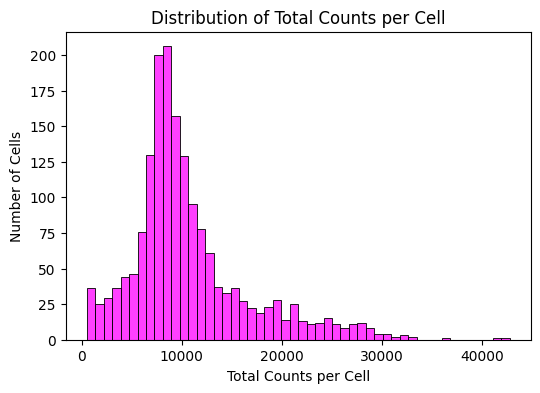

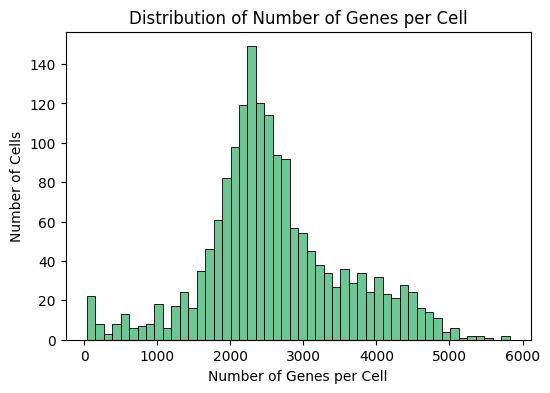

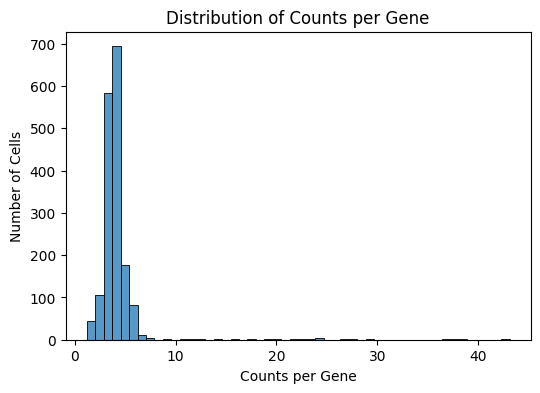

In [40]:
# Histogram of total counts per cell
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["n_counts"], bins=50, kde=False, color="magenta")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Total Counts per Cell")
plt.show()


# Histogram of number of genes per cell
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["n_genes"], bins=50, kde=False, color="mediumseagreen")
plt.xlabel("Number of Genes per Cell")
plt.ylabel("Number of Cells")
plt.title("Distribution of Number of Genes per Cell")
plt.show()


# Histogram of counts per gene
plt.figure(figsize=(6, 4))
sns.histplot(adata.obs["counts_per_gene"], bins=50, kde=False)
plt.xlabel("Counts per Gene")
plt.ylabel("Number of Cells")
plt.title("Distribution of Counts per Gene")
plt.show()


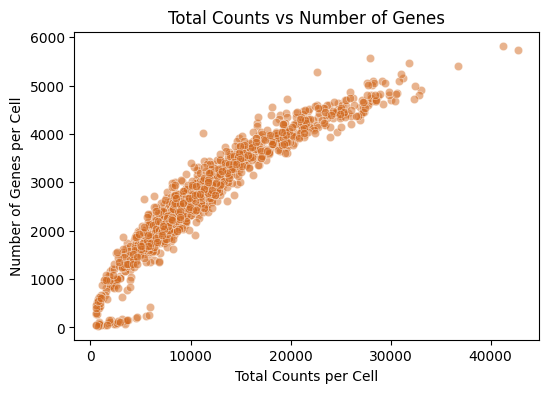

In [44]:
# Scatter plot of total counts vs number of genes
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata.obs, alpha=0.5, color="chocolate")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes")
plt.show()

/tmp/ipykernel_5504/434907653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_counts", data=adata.obs, palette=["#4C78A8", "#E45756"] )
/tmp/ipykernel_5504/434907653.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_genes", data=adata.obs, palette=["#E98B50", "#2196F3"] )


Text(0.5, 1.0, 'Number of Genes per Cell by Sample')

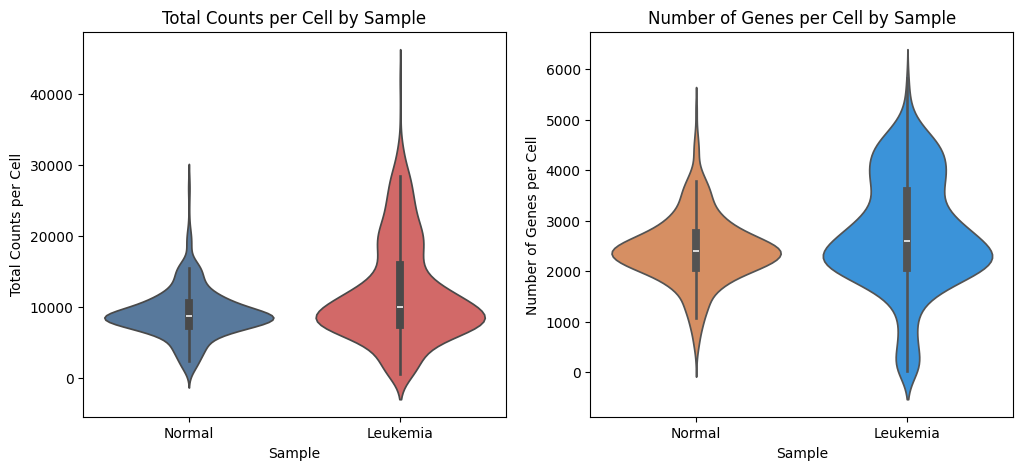

In [45]:
# Make voilen plot of n_counts per sample & n_genes per sample
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x="sample", y="n_counts", data=adata.obs, palette=["#4C78A8", "#E45756"] )
plt.xlabel("Sample")
plt.ylabel("Total Counts per Cell")
plt.title("Total Counts per Cell by Sample")

plt.subplot(1, 2, 2)
sns.violinplot(x="sample", y="n_genes", data=adata.obs, palette=["#E98B50", "#2196F3"] )
plt.xlabel("Sample")
plt.ylabel("Number of Genes per Cell")
plt.title("Number of Genes per Cell by Sample")

In [46]:
print("Cells before filtering:", adata.n_obs)
print("Genes before filtering:", adata.n_vars)

Cells before filtering: 1731
Genes before filtering: 36601


In [47]:
# Check quantiles
adata.obs["n_counts"].quantile([0.01, 0.99])

,n_counts
0.01,805.2
0.99,29346.8


In [48]:
# Check quantiles
adata.obs["n_genes"].quantile([0.01, 0.99])

,n_genes
0.01,117.3
0.99,4900.1


In [49]:
# Check quantiles
adata.obs["counts_per_gene"].quantile([0.01, 0.99])

,counts_per_gene
0.01,1.573973
0.99,20.221891


In [50]:
## Compute quantile thresholds
n_counts_low, n_counts_high = adata.obs["n_counts"].quantile([0.01, 0.99])
n_genes_low, n_genes_high = adata.obs["n_genes"].quantile([0.01, 0.99])
complex_low, complex_high = adata.obs["counts_per_gene"].quantile([0.01, 0.99])

# Define mito and ribo thresholds (biologically guided)
mito_threshold = 15        # Common practice: < 10–20%
ribo_threshold = 40        # Dataset dependent, often < 40–50%

# Apply all filters together
adata_filtered = adata[
    (adata.obs["n_counts"] >= n_counts_low) &
    (adata.obs["n_counts"] <= n_counts_high) &
    (adata.obs["n_genes"] >= n_genes_low) &
    (adata.obs["n_genes"] <= n_genes_high) &
    (adata.obs["counts_per_gene"] >= complex_low) &
    (adata.obs["counts_per_gene"] <= complex_high) &
    (adata.obs["pct_counts_mt"] < mito_threshold) &
    (adata.obs["pct_counts_ribo"] < ribo_threshold),
    :
].copy()

In [51]:
print("Cells after filtering:", adata_filtered.n_obs)
print("Genes after filtering:", adata_filtered.n_vars)
print("Cells removed:", adata.n_obs - adata_filtered.n_obs)

Cells after filtering: 323
Genes after filtering: 36601
Cells removed: 1408


In [52]:
# Export filtered QC metrics
adata_filtered.obs.to_csv("QC_filtered_table.csv")

In [53]:
adata_filtered.shape

(323, 36601)

In [54]:
adata.shape

(1731, 36601)

/tmp/ipykernel_5504/3798222079.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_counts", data=adata_filtered.obs, palette= ["#CF4173", "#1B5E20"])
/tmp/ipykernel_5504/3798222079.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sample", y="n_genes", data=adata_filtered.obs, palette=["#4E1F6E", "#45A9A9"])


Text(0.5, 1.0, 'Number of Genes per Cell by Sample (Filtered)')

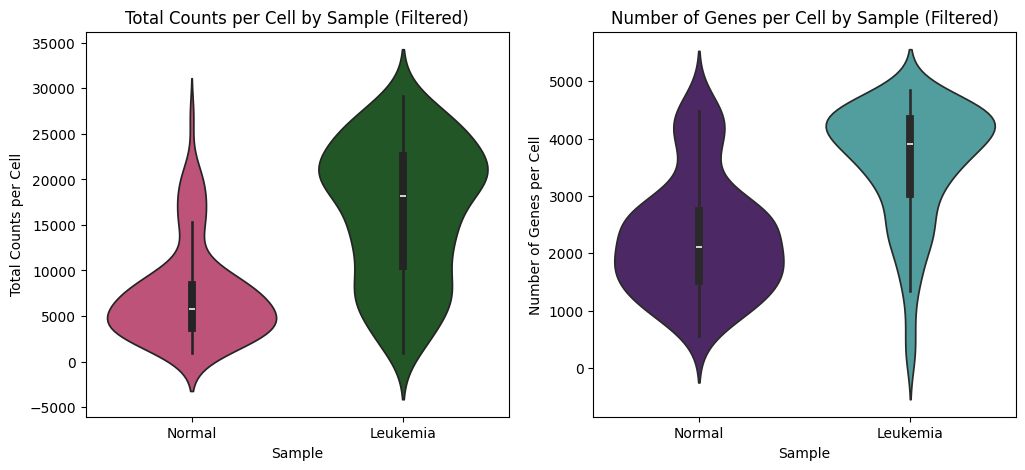

In [59]:
# make voilen plot of n_counts per sample & n_genes per sample after filtering
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x="sample", y="n_counts", data=adata_filtered.obs, palette= ["#CF4173", "#1B5E20"])
plt.xlabel("Sample")
plt.ylabel("Total Counts per Cell")
plt.title("Total Counts per Cell by Sample (Filtered)")

plt.subplot(1, 2, 2)
sns.violinplot(x="sample", y="n_genes", data=adata_filtered.obs, palette=["#4E1F6E", "#45A9A9"])
plt.xlabel("Sample")
plt.ylabel("Number of Genes per Cell")
plt.title("Number of Genes per Cell by Sample (Filtered)")

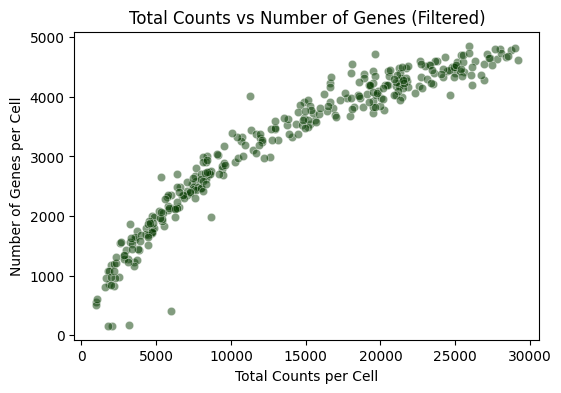

In [61]:
# scatter plot of total counts vs number of genes after filtering
plt.figure(figsize=(6, 4))
sns.scatterplot(x="n_counts", y="n_genes", data=adata_filtered.obs, alpha=0.5, color="#063B00")
plt.xlabel("Total Counts per Cell")
plt.ylabel("Number of Genes per Cell")
plt.title("Total Counts vs Number of Genes (Filtered)")
plt.show()

In [62]:
# Freeze raw counts after QC filtering
adata_filtered.raw = adata_filtered.copy()

In [63]:
# Check the shape of the raw counts after filtering
adata_filtered.raw.X.shape

(323, 36601)

In [64]:
# Normalize counts (library-size normalization)

sc.pp.normalize_total(
    adata_filtered,
    target_sum=1e4
)

In [65]:
# Total counts per cell (raw)
adata_filtered.obs["total_counts_raw"] = (
    adata_filtered.raw.X.sum(axis=1).A1
)

# Total counts per cell (normalized)
adata_filtered.obs["total_counts_normalized"] = (
    adata_filtered.X.sum(axis=1).A1
)
# Check the first few rows of obs to see the new total counts columns
adata_filtered.obs[["total_counts_raw", "total_counts_normalized"]].head()

,total_counts_raw,total_counts_normalized
AAACGGGAGCAATATG-1,19622.0,10000.000000
ACCCACTAGTCCATAC-1,7594.0,9999.999023
ACGGCCAGTGCGAAAC-1,4642.0,10000.000000
ACGGGTCCACGAGGTA-1,1955.0,10000.000000
ACTTGTTCAGCATACT-1,6703.0,10000.000000


In [66]:
# Log transform normalized data
sc.pp.log1p(adata_filtered)

In [67]:
# Preserve log-normalized expression
adata_filtered.layers["lognorm"] = adata_filtered.X.copy()

In [68]:
# Identify highly variable genes (HVGs)
sc.pp.highly_variable_genes(
    adata_filtered,
    flavor="seurat",
    n_top_genes=2000
)

In [69]:
# Check the first few rows of var to see the new highly variable gene columns
adata_filtered.var.head()


,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
MIR1302-2HG,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
FAM138A,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
OR4F5,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN
AL627309.1,False,False,2,0.001155,99.88446,2.0,False,1.506009e-03,-0.719886,-1.527475
AL627309.3,False,False,0,0.000000,100.00000,0.0,False,1.000000e-12,NaN,NaN


In [70]:
# Chaeck the number of rows and columns in the adata_filtered.var DataFrame
adata_filtered.var.shape

(36601, 10)

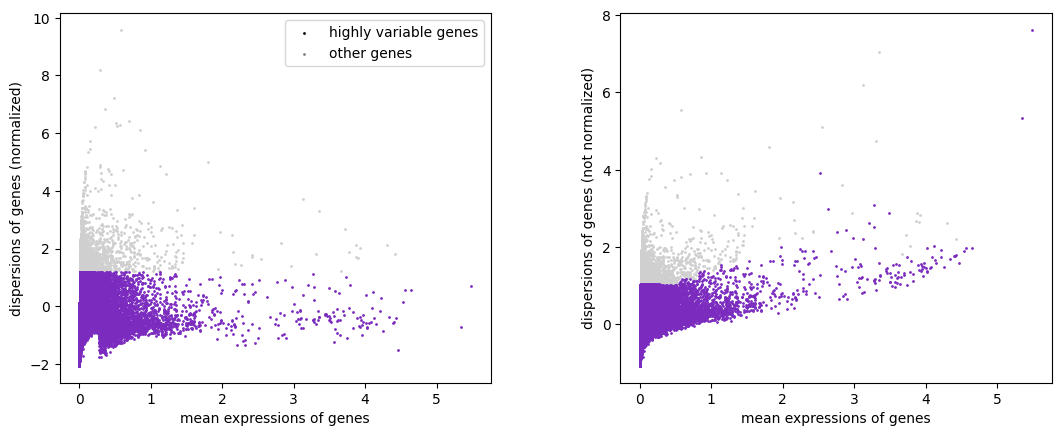

In [74]:
# Visualize highly variable genes in normalized mean vs normalized variance plot
sc.pl.highly_variable_genes(adata_filtered, show =False)

# Get the current figure
fig = plt.gcf()

# Change the point colors
for ax in fig.axes:
    if len(ax.collections) >= 2:
        ax.collections[0].set_color("#CFCFCF")  # other genes
        ax.collections[1].set_color("#7B2CBF")  # highly variable genes

plt.show()

In [75]:
# Export HVG statistics to CSV
hvg_stats = adata_filtered.var.copy()
hvg_stats.to_csv("HVG_statistics_full.csv")

In [76]:
# Extract only the highly variable genes
hvg_only = adata_filtered.var[
    adata_filtered.var["highly_variable"]
]
hvg_only.head()


,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC00115,False,False,10,0.005777,99.422299,10.0,True,0.026996,1.402160,1.730687
TNFRSF4,False,False,23,0.015020,98.671288,26.0,True,0.060030,1.221078,1.452655
ATAD3C,False,False,32,0.019064,98.151358,33.0,True,0.020780,1.056968,1.200683
SKI,False,False,185,0.119006,89.312536,206.0,True,0.179933,1.312980,1.593760
KCNAB2,False,False,465,0.359330,73.136915,622.0,True,0.215425,1.182480,1.393392


In [77]:
# number of rows and columns in the hvg_only DataFrame
hvg_only.shape

(2000, 10)

In [78]:
# Export only the highly variable genes statistics to CSV
hvg_only.to_csv("HVG_statistics_HVGonly.csv")

In [79]:
adata_hvg = adata_filtered[
    :, adata_filtered.var["highly_variable"]
].copy()

In [80]:
# Convert the sparse matrix of highly variable genes to a DataFrame
expr_df = pd.DataFrame(
    adata_hvg.X.toarray(),
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

expr_df.head()


,LINC00115,TNFRSF4,ATAD3C,SKI,KCNAB2,ERRFI1,RERE,SLC2A5,GPR157,RBP7,...,AL683813.1,Z96074.1,FGF13,IDS,PLXNA3,IL9R,MT-CO1,MT-CO2,MT-CO3,MT-ND4
AAACGGGAGCAATATG-1,0.0,0.000000,0.0,0.0,0.411866,0.0,0.927783,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,3.889888,3.979534,3.825323,3.950536
ACCCACTAGTCCATAC-1,0.0,0.000000,0.0,0.0,0.000000,0.0,1.599486,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.840199,0.0,0.0,4.314048,4.053933,3.958073,4.120242
ACGGCCAGTGCGAAAC-1,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,1.148749,1.669307,0.0,0.0,3.439116,3.439116,3.833826,3.736017
ACGGGTCCACGAGGTA-1,0.0,0.000000,0.0,0.0,0.000000,0.0,2.418605,0.0,0.0,0.0,...,0.0,0.0,0.000000,2.418605,0.0,0.0,4.685984,4.533369,4.685984,4.732084
ACTTGTTCAGCATACT-1,0.0,0.913033,0.0,0.0,0.000000,0.0,1.382221,0.0,0.0,0.0,...,0.0,0.0,0.000000,1.941253,0.0,0.0,3.521086,3.886496,3.974348,3.379140


In [81]:
# Export the expression matrix of highly variable genes to CSV
expr_df.to_csv("HVG_expression_matrix.csv")

In [82]:
adata_hvg.shape

(323, 2000)

In [83]:
# Shape of raw matrix
adata.X.shape

(1731, 36601)

In [84]:
# shape of matrix after QC
adata_filtered.raw.shape

(323, 36601)

In [85]:
# shape of log-normalized matrix
adata_filtered.layers["lognorm"].shape

(323, 36601)

In [86]:
# Shape of matrix with only highly variable genes
adata_hvg.shape

(323, 2000)

In [87]:
# Scale HVGs
sc.pp.scale(
    adata_hvg,
    max_value=10   # clipping extreme values (important for scRNA-seq)
)

In [88]:
# Check scaled matrix head
scaled_df = pd.DataFrame(
    adata_hvg.X[:10, :10],
    index=adata_hvg.obs_names[:10],
    columns=adata_hvg.var_names[:10]
)
scaled_df

,LINC00115,TNFRSF4,ATAD3C,SKI,KCNAB2,ERRFI1,RERE,SLC2A5,GPR157,RBP7
AAACGGGAGCAATATG-1,-0.095419,-0.153303,-0.090005,-0.315538,0.834503,-0.055641,0.253580,-0.188200,-0.071329,-0.063532
ACCCACTAGTCCATAC-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,1.191164,-0.188200,-0.071329,-0.063532
ACGGCCAGTGCGAAAC-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,-1.041448,-0.188200,-0.071329,-0.063532
ACGGGTCCACGAGGTA-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,2.334515,-0.188200,-0.071329,-0.063532
ACTTGTTCAGCATACT-1,-0.095419,4.626137,-0.090005,-0.315538,-0.375275,-0.055641,0.887898,-0.188200,-0.071329,-0.063532
AGACGTTTCCGCATCT-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,1.275895,-0.188200,-0.071329,-0.063532
AGCAGCCAGTCATGCT-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,-1.041448,-0.188200,-0.071329,-0.063532
AGTCTTTAGTGGTAAT-1,-0.095419,-0.153303,-0.090005,3.299312,-0.375275,-0.055641,2.095648,-0.188200,-0.071329,-0.063532
AGTGAGGCAATGCCAT-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,2.189785,9.713949,-0.071329,-0.063532
ATAGACCGTCGTCTTC-1,-0.095419,-0.153303,-0.090005,-0.315538,-0.375275,-0.055641,-1.041448,-0.188200,-0.071329,-0.063532


In [89]:
# Principal Component Analysis (PCA)

# Step 1: Perform PCA
# Input: scaled HVG matrix (adata_hvg)
# svd_solver="arpack" -> efficient solver for large datasets
sc.tl.pca(
    adata_hvg,
    svd_solver="arpack"
)

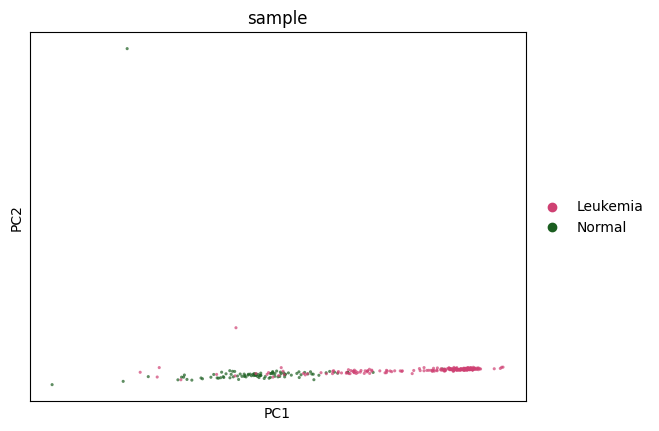

In [90]:
# Step 2: visualize PCA embedding colored by sample
sc.pl.pca(
    adata_hvg,
    color="sample",      # color points by sample metadata
    palette=["#CF4173", "#1B5E20"],  # Leukemia, Normal
    size=20,             # adjust marker size for clarity
    alpha=0.7            # transparency to see overlapping cells
)


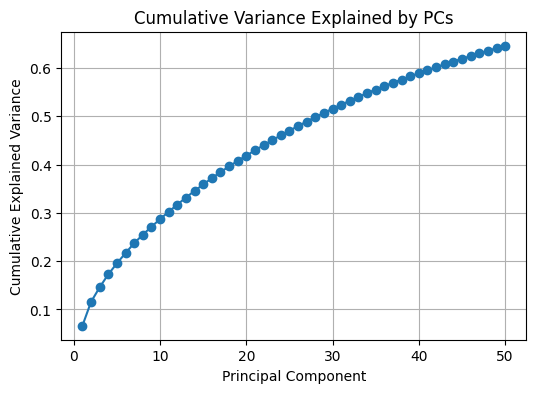

In [91]:
# Step 3: Compare variance captured by first few PCs vs remaining
explained_variance = adata_hvg.uns["pca"]["variance_ratio"]
cumulative_var = explained_variance.cumsum()
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCs")
plt.grid(True)
plt.show()

In [92]:
# Step 4: Inspect PCA output – explained variance
print("Explained variance ratio (first 10 PCs):")
print(adata_hvg.uns["pca"]["variance_ratio"][:10])

Explained variance ratio (first 10 PCs):
[0.06627424 0.04934518 0.03021429 0.02685243 0.02275275 0.02130532
 0.02037008 0.01760665 0.01645197 0.01576288]


In [93]:
# Step 5: Inspect gene loadings for PC1
# This shows which genes contribute most to PC1
pc1_genes = pd.Series(
    adata_hvg.varm["PCs"][:, 0],  # loadings of PC1
    index=adata_hvg.var_names
).sort_values(ascending=False)
print("Top 10 genes contributing to PC1:")
print(pc1_genes.head(10))

Top 10 genes contributing to PC1:
BLVRB       0.085184
PRDX2       0.083877
S100A6      0.083288
HBA1        0.081094
HBD         0.074360
HBA2        0.070278
CA2         0.066449
FTH1        0.059768
SLC25A37    0.057682
RPL8        0.055362
dtype: float64


In [94]:
# Step 6: Export PCA coordinates to CSV
pca_coords = pd.DataFrame(
    adata_hvg.obsm["X_pca"],
    index=adata_hvg.obs_names,
    columns=[f"PC{i+1}" for i in range(adata_hvg.obsm["X_pca"].shape[1])]
)
pca_coords.to_csv("PCA_coordinates.csv")

In [95]:
# Step 7: Check how many PCs are needed to cover 80% of variance
n_pcs_80 = sum(cumulative_var < 0.80)
print(f"Number of PCs to cover ~80% variance: {n_pcs_80}")

Number of PCs to cover ~80% variance: 50


In [96]:
# Step 8: Top genes per PC
top_genes_per_pc = adata_hvg.varm["PCs"][:, :5]  # first 5 PCs
top_genes_idx = [list(np.argsort(-abs(top_genes_per_pc[:,i]))[:5]) for i in range(5)]
for i, idx in enumerate(top_genes_idx):
    genes = adata_hvg.var_names[idx]
    print(f"Top genes for PC{i+1}: {list(genes)}")

Top genes for PC1: ['BLVRB', 'PRDX2', 'S100A6', 'HBA1', 'FOS']
Top genes for PC2: ['TEAD1', 'ADIRF', 'LAMA4', 'PPARG', 'CNN3']
Top genes for PC3: ['MS4A1', 'PLEKHG1', 'IGKC', 'IGHM', 'CD79A']
Top genes for PC4: ['LDLRAD3', 'PALM2-AKAP2', 'ARHGAP31', 'CTTNBP2NL', 'PDGFB']
Top genes for PC5: ['AC092652.2', 'HLF', 'AC133919.1', 'IL4R', 'LRRC37A2']


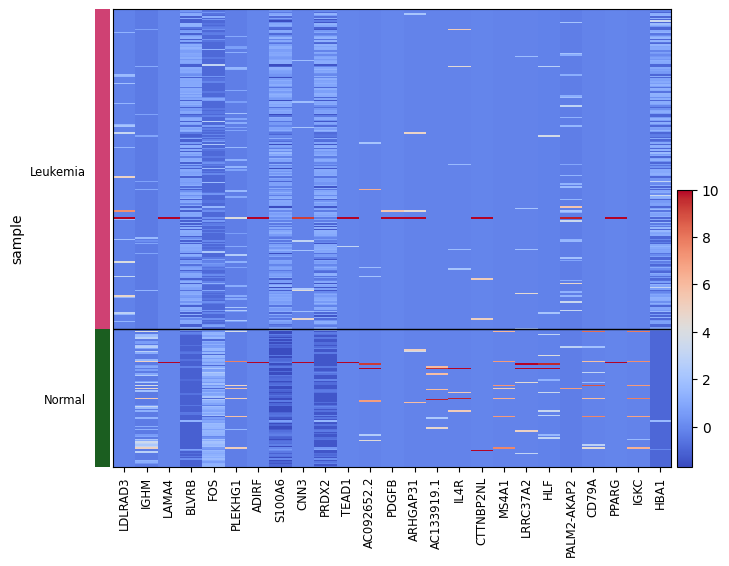

In [101]:
# Step 9: heatmap of top genes per PC (optional)
top_genes = set()
for idx in top_genes_idx:
    top_genes.update(adata_hvg.var_names[idx])
top_genes = list(top_genes)
# Assign colors to the sample categories
adata_hvg.uns["sample_colors"] = ["#CF4173", "#1B5E20"]
sc.pl.heatmap(
    adata_hvg,
    var_names=top_genes,
    groupby="sample",
    use_raw=False,
    show_gene_labels=True,
    cmap="coolwarm",

)

In [102]:
# =============================
# Step 1: Compute the neighborhood graph
# =============================

# Input: scaled HVG matrix (adata_hvg) with PCA already computed
# n_neighbors = 15 -> each cell is connected to its 15 closest neighbors
# n_pcs = 30 -> use first 30 PCs to calculate distances
sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=30
)

# Teaching explanation:
# Each cell is now connected to its 'closest' cells in PC space.
# Think of it as creating a "friendship network" among cells:
#   - Each cell has 15 closest friends (neighbors)
#   - Distance between friends = similarity in gene expression

In [103]:
# Step 2: Inspect the distance matrix
dist_matrix = adata_hvg.obsp["distances"].toarray()  # convert sparse matrix to dense
dist_matrix.shape  # should be (n_cells, n_cells)

(323, 323)

In [104]:
# Ignore diagonal (distance of a cell to itself)
np.fill_diagonal(dist_matrix, np.nan)

# Maximum distance
max_dist = np.nanmax(dist_matrix)
max_idx = np.unravel_index(np.nanargmax(dist_matrix), dist_matrix.shape)

print(f"Max distance: {max_dist}")
print(f"Between cells: {adata_hvg.obs_names[max_idx[0]]} and {adata_hvg.obs_names[max_idx[1]]}")

Max distance: 156.40602111816406
Between cells: CATCGGGAGGACGAAA-1 and GTCGTAATCTTCTGGC-1


In [105]:
# Minimum distance (closest neighbors)
min_dist = np.nanmin(dist_matrix)
min_idx = np.unravel_index(np.nanargmin(dist_matrix), dist_matrix.shape)

print(f"Min distance: {min_dist}")
print(f"Between cells: {adata_hvg.obs_names[min_idx[0]]} and {adata_hvg.obs_names[min_idx[1]]}")

Min distance: 0.0
Between cells: AAACGGGAGCAATATG-1 and ACCCACTAGTCCATAC-1


In [106]:
# Compute UMAP embedding from the neighborhood graph
sc.tl.umap(
    adata_hvg,
    min_dist=0.3,   # controls cluster compactness (How close cells are allowed to stand together)
    spread=1.0      # controls global separation
)

In [107]:
# UMAP coordinates (2D embedding)
umap_df = pd.DataFrame(
    adata_hvg.obsm["X_umap"],
    index=adata_hvg.obs_names,
    columns=["UMAP1", "UMAP2"]
)

umap_df.head()

,UMAP1,UMAP2
AAACGGGAGCAATATG-1,1.135000,11.237242
ACCCACTAGTCCATAC-1,2.644059,14.041091
ACGGCCAGTGCGAAAC-1,3.543998,12.666663
ACGGGTCCACGAGGTA-1,2.447857,13.787305
ACTTGTTCAGCATACT-1,2.753584,13.777581


In [108]:
umap_df.to_csv("UMAP_embeddings_cells.csv")

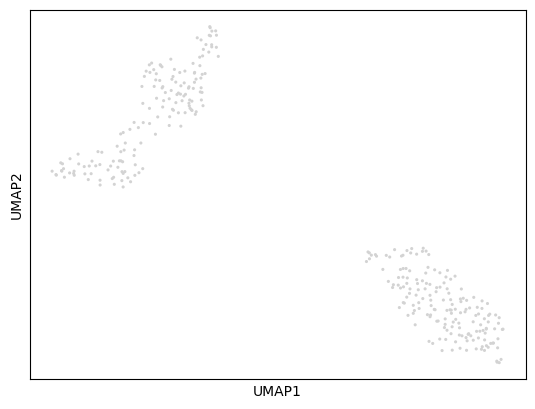

In [109]:
# Plain UMAP (structure only)
sc.pl.umap(
    adata_hvg,
    size=20
)

In [110]:
# Check the category order first
print(adata_hvg.obs["sample"].cat.categories)

Index(['Leukemia', 'Normal'], dtype='object')


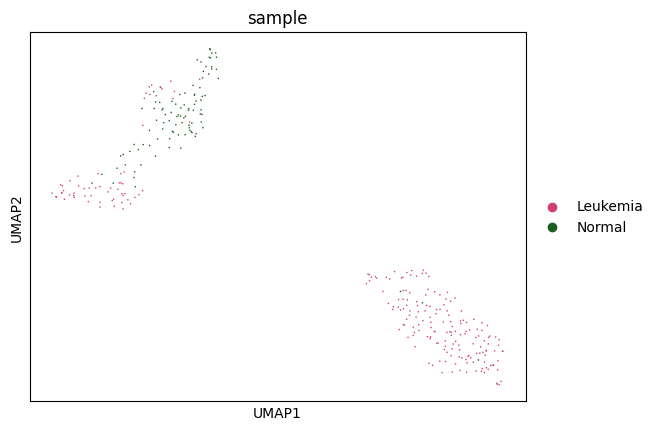

In [111]:
# Set colors in the same order as the categories
adata_hvg.uns["sample_colors"] = [
    "#CF4173",  # Leukemia — pink/red
    "#1B5E20"   # Normal — dark green
]
# UMAP colored by sample identity
sc.pl.umap(
    adata_hvg,
    color="sample",
    size=5
)

In [112]:
 pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 22.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [leidenalg]


In [113]:
import leidenalg

In [122]:
# Run Leiden clustering on the neighbor graph
sc.tl.leiden(
    adata_hvg,
    resolution=0.7,
    key_added="leiden_0.7"
)

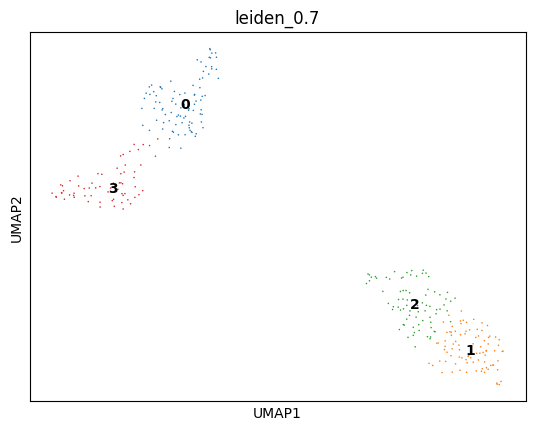

In [123]:
# Visualize UMAP colored by Leiden clusters
sc.pl.umap(
    adata_hvg,
    color="leiden_0.7",
    legend_loc="on data",
    size=5
)

In [124]:
# Run Leiden clustering at multiple resolutions
for res in [0.2, 0.3, 0.5, 0.7, 1.0]:
    sc.tl.leiden(
        adata_hvg,
        resolution=res,
        key_added=f"leiden_{res}"
    )

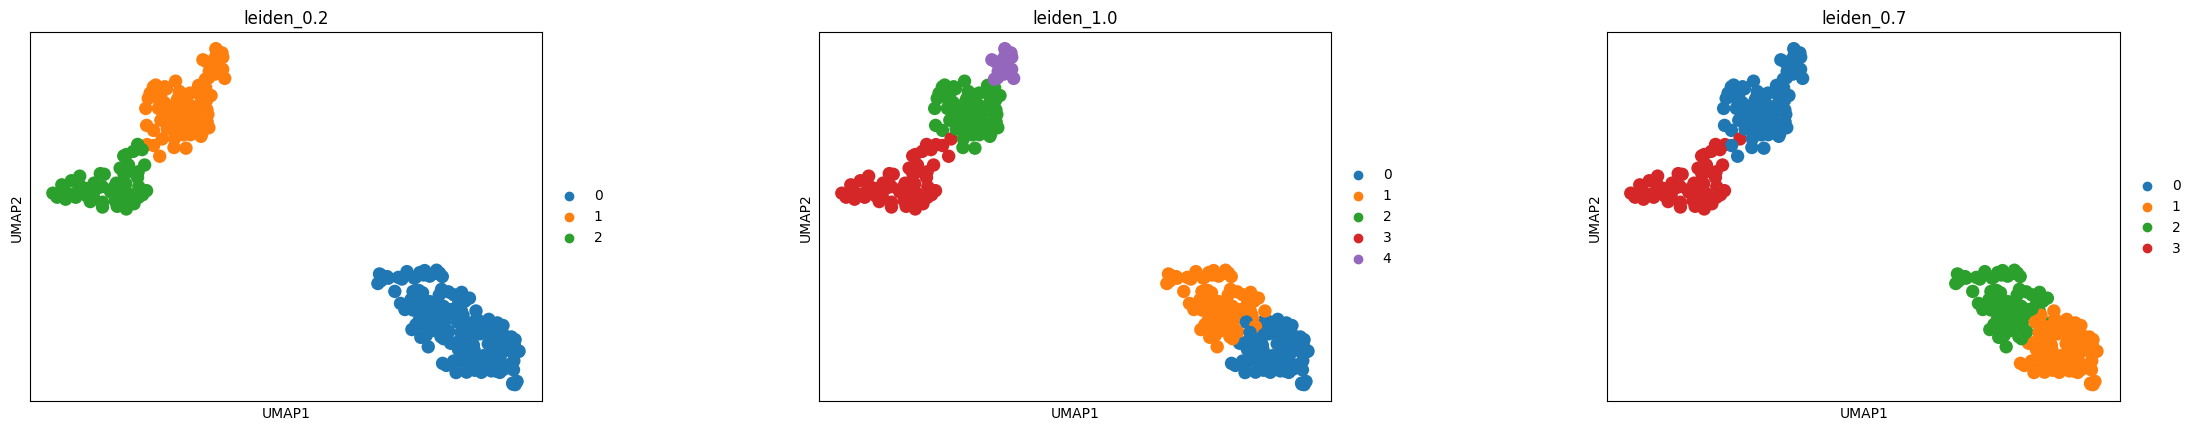

In [125]:
# Visualize UMAP colored by Leiden clusters at multiple resolutions
sc.pl.umap(
    adata_hvg,
    color=["leiden_0.2", "leiden_1.0", "leiden_0.7"],
    wspace=0.4
)

In [126]:
# Check the number of clusters at each resolution
adata_hvg.obs["leiden_0.7"].value_counts()

,count
leiden_0.7,
0,93
1,88
2,79
3,63


In [127]:
# Export cluster assignments to CSV
adata_hvg.obs["leiden_0.7"].value_counts().to_csv(
    "Cluster_Cell_Counts.csv"
)

In [128]:
cluster_df = adata_hvg.obs[["sample", "leiden_0.7"]]
cluster_df.to_csv("Cell_Clusters_Leiden_0.7.csv")
cluster_df.head()

,sample,leiden_0.7
AAACGGGAGCAATATG-1,Normal,3
ACCCACTAGTCCATAC-1,Normal,0
ACGGCCAGTGCGAAAC-1,Normal,0
ACGGGTCCACGAGGTA-1,Normal,0
ACTTGTTCAGCATACT-1,Normal,0


In [129]:
adata_filtered.obs["leiden_0.7"] = adata_hvg.obs["leiden_0.7"]

In [130]:
# View the first few rows
adata_filtered.obs["leiden_0.7"].head()

,leiden_0.7
AAACGGGAGCAATATG-1,3
ACCCACTAGTCCATAC-1,0
ACGGCCAGTGCGAAAC-1,0
ACGGGTCCACGAGGTA-1,0
ACTTGTTCAGCATACT-1,0


In [131]:
adata_filtered.layers["lognorm"].shape

(323, 36601)

In [132]:
# Marker genes for Leiden clusters at resolution 0.7
sc.tl.rank_genes_groups(
    adata_filtered,
    groupby="leiden_0.7",
    method="wilcoxon",
    layer="lognorm",     # uses log1p layer
    pts=True,
    use_raw=False        # ← important
)

In [133]:
# Export all marker genes for all clusters to CSV
marker_df = sc.get.rank_genes_groups_df(
    adata_filtered,
    group=None           # all clusters
)

marker_df.to_csv("Cluster_Marker_Genes.csv", index=False)
marker_df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CD74,13.513977,4.059042,1.293415e-41,4.734027e-37,0.989247,0.817391
1,0,HLA-DRA,11.859929,3.344188,1.911367e-32,1.399159e-28,0.956989,0.778261
2,0,HLA-DPB1,11.440825,3.769368,2.613884e-30,1.195885e-26,0.903226,0.421739
3,0,HLA-DRB1,11.399375,3.667603,4.211316e-30,1.712648e-26,0.892473,0.508696
4,0,MALAT1,11.382269,1.994729,5.124892e-30,1.875762e-26,1.000000,0.986957


In [134]:
# Define thresholds
LOGFC_CUTOFF = 1
PVALUE_CUTOFF = 0.05
PCT_GROUP_CUTOFF = 0.25
PCT_REF_CUTOFF = 0.25

# Extract the marker table
deg_df = sc.get.rank_genes_groups_df(
    adata_filtered,
    group=None
)

# Apply all gold-standard filters
filtered_deg_df = deg_df[
    (deg_df["pvals_adj"] <= PVALUE_CUTOFF) &
    ((deg_df["logfoldchanges"] >= LOGFC_CUTOFF) |
     (deg_df["logfoldchanges"] <= -LOGFC_CUTOFF)) &
    (deg_df["pct_nz_group"] >= PCT_GROUP_CUTOFF) &
    (deg_df["pct_nz_reference"] <= PCT_REF_CUTOFF)
].copy()

# Save refined markers
filtered_deg_df.to_csv("Refined_Marker_Genes_GoldStandard.csv", index=False)

# View top markers
for cluster in filtered_deg_df["group"].unique():
    print(f"\nCluster {cluster} top markers:")
    display(filtered_deg_df[filtered_deg_df["group"]==cluster].head(5))


Cluster 0 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
5,0,SPINK2,11.198047,7.502980,4.168212e-29,1.089719e-25,0.806452,0.052174
6,0,CD52,10.813813,5.047737,2.961003e-27,5.418784e-24,0.806452,0.173913
18,0,HLA-DRB5,9.110420,4.202339,8.206329e-20,2.422257e-17,0.709677,0.152174
19,0,ATP8B4,9.078839,4.418639,1.097385e-19,3.137921e-17,0.709677,0.152174
20,0,PLCB1,9.028178,3.999104,1.745527e-19,4.767763e-17,0.709677,0.139130



Cluster 1 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
36608,1,GYPA,10.696101,3.806644,1.061514e-26,4.856558e-23,0.852273,0.136170
36609,1,ALAS2,10.611790,3.651635,2.626675e-26,1.068210e-22,0.875000,0.153191
36630,1,TSPAN17,9.244750,2.636488,2.357909e-20,2.397273e-17,0.840909,0.229787
36633,1,GYPB,9.165792,3.539566,4.918427e-20,4.390716e-17,0.750000,0.110638
36641,1,TLCD4,8.665950,2.484184,4.477651e-18,3.213461e-15,0.806818,0.187234



Cluster 2 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
73223,2,PNMT,7.044405,2.561122,1.862556e-12,3.098701e-09,0.670886,0.180328
73297,2,SCO2,5.840535,1.747361,5.203334e-09,1.874914e-06,0.658228,0.233607
73352,2,AC073210.3,5.469048,1.633670,4.524601e-08,1.041540e-05,0.632911,0.250000
73375,2,PMP22,5.235482,1.793515,1.645552e-07,3.273306e-05,0.569620,0.192623
73413,2,ZNF670,5.031718,1.621163,4.861042e-07,7.872522e-05,0.594937,0.241803



Cluster 3 top markers:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
109803,3,GP1BB,11.516837,5.808158,1.085213e-30,3.971988e-26,0.952381,0.215385
109804,3,PLEK,11.202564,6.016090,3.960997e-29,7.248822e-25,0.936508,0.080769
109808,3,ITGA2B,9.917653,5.982040,3.488640e-23,2.128129e-19,0.825397,0.073077
109809,3,AL157895.1,9.740968,6.412565,2.016246e-22,1.054238e-18,0.809524,0.034615
109810,3,PKM,9.545487,3.898625,1.354697e-21,6.197908e-18,0.873016,0.138462


In [135]:
# save refined markers
filtered_deg_df.to_csv("Refined_Marker_Genes.csv", index=False)

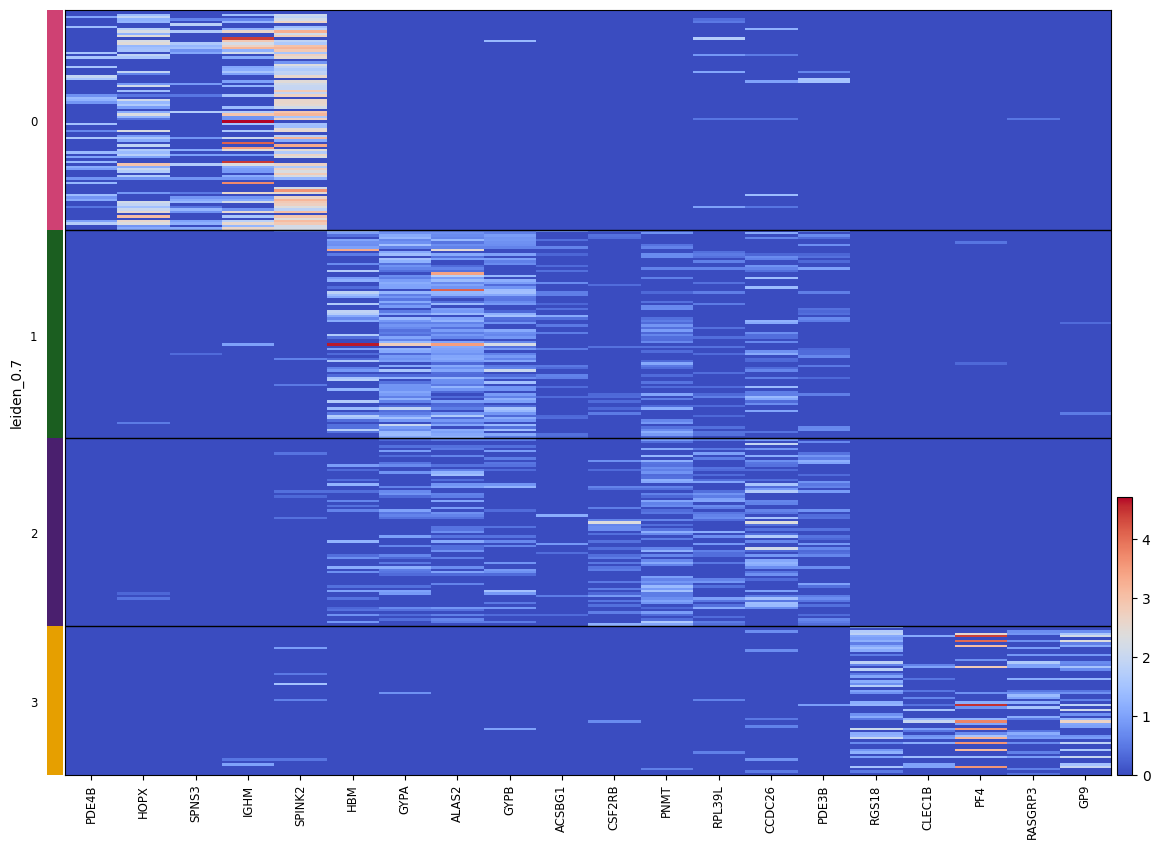

In [139]:
# Select top 5 markers per cluster
top_n = 5
top_markers = (
    filtered_deg_df.groupby("group")
    .apply(lambda x: x.nlargest(top_n, "logfoldchanges"))
    .reset_index(drop=True)
)

# Extract gene names
genes_to_plot = top_markers["names"].unique().tolist()

# Custom colors for Leiden clusters
adata_filtered.uns["leiden_0.7_colors"] = [
    "#CF4173",  # Cluster 0
    "#1B5E20",  # Cluster 1
    "#4A1F6E",  # Cluster 2
    "#E69F00",  # Cluster 3
    "#0072B2"   # Cluster 4
]
# Heatmap using Scanpy
sc.pl.heatmap(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.7",
    use_raw=False,       # uses lognorm layer
    layer="lognorm",
    swap_axes=False,     # clusters on y-axis, genes on x-axis
    cmap="coolwarm",
    show_gene_labels=True,
    figsize=(14,10)
)

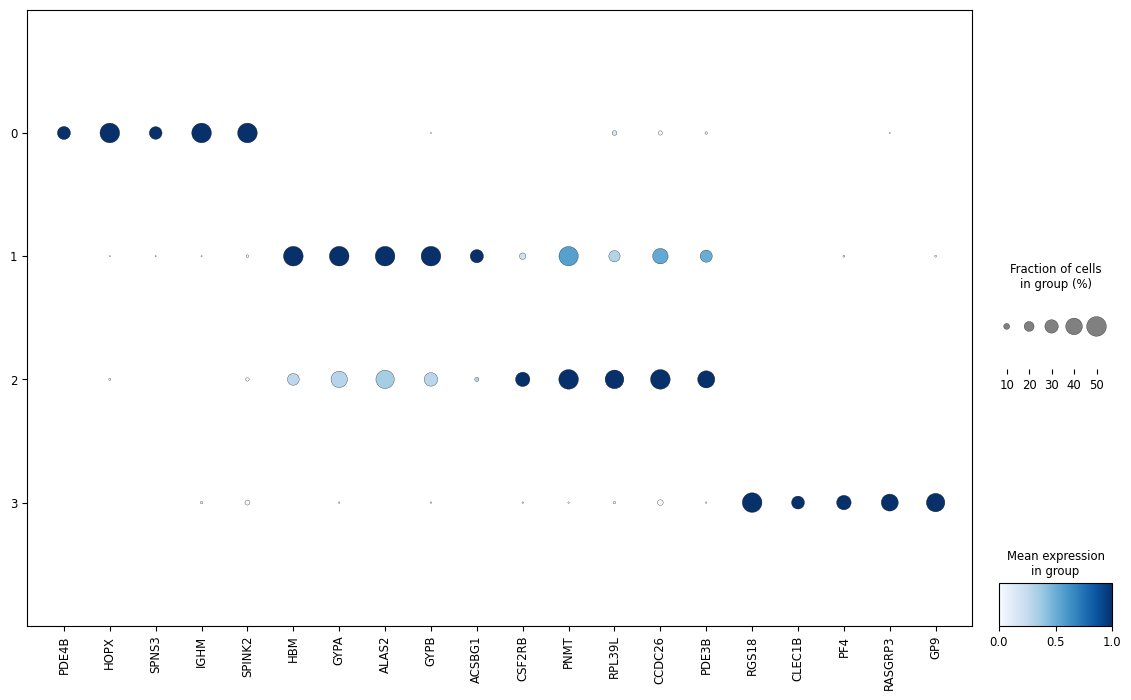

In [143]:
# Dotplot using Scanpy
sc.pl.dotplot(
    adata_filtered,
    var_names=genes_to_plot,
    groupby="leiden_0.7",
    use_raw=False,
    layer="lognorm",
    standard_scale="var",  # scales each gene to [0,1] for comparability
    dot_max=0.5,
    figsize=(14,8),
    cmap="Blues"
)

In [144]:
pip install celltypist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 39.3 MB/s  0:00:00


In [145]:
# CellTypist for automated cell type annotation
import celltypist
from celltypist import models

In [146]:
# Show all available models (locally downloaded or from remote index)
model_list_df = models.models_description(on_the_fly=True)

print(model_list_df)

                               model  \
0          Adult_cHSPCs_Illumina.pkl   
1             Fetal_Human_Retina.pkl   
2            Adult_cHSPCs_Ultima.pkl   
3          Adult_Pig_Hippocampus.pkl   
4            Healthy_Adult_Heart.pkl   
..                               ...   
56        Developing_Human_Brain.pkl   
57                Immune_All_Low.pkl   
58              Cells_Fetal_Lung.pkl   
59  Developing_Mouse_Hippocampus.pkl   
60          Fetal_Human_Pancreas.pkl   

                                          description  
0   human circulating hematopoietic stem and proge...  
1   cell types from human fetal neural retina and ...  
2   human circulating hematopoietic stem and proge...  
3           cell types from the adult pig hippocampus  
4   cell types from eight anatomical regions of th...  
..                                                ...  
56  cell types from the first-trimester developing...  
57  immune sub-populations combined from 20 tissue...  
58    cell type

In [147]:
adata_filtered

AnnData object with n_obs × n_vars = 323 × 36601
    obs: 'sample', 'sample_id', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.7'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.7_colors'
    layers: 'lognorm'

In [148]:
# Make a copy of your filtered AnnData
adata_ct = adata_filtered.copy()

In [149]:
# Use the log-normalized data for CellTypist
adata_ct.X = adata_filtered.layers["lognorm"]

In [150]:
adata_ct.shape

(323, 36601)

In [196]:
from celltypist import models, annotate

# Load the model
model = models.Model.load("Adult_cHSPCs_Illumina.pkl")

In [197]:
# Model description
models.models_description()

,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [198]:
# Run annotation with majority voting
predictions = annotate(
    adata_ct,
    model=model,
    majority_voting=True
)

In [199]:
predictions

CellTypist prediction result for 323 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 323 query cells and 20 cell types
    probability_matrix: data frame with 323 query cells and 20 cell types
    adata: AnnData object referred

In [200]:
predictions.adata.obs.shape

(323, 15)

In [201]:
# Check the predicted labels
predictions.predicted_labels.majority_voting.value_counts()

,count
majority_voting,
ERYP,168
HSC_MPP,66
MKP,49
MEBEMP-L,19
CLP,14
B,5
GMP-L,2


In [202]:
# Remove duplicated indices (if any) from predicted labels
predicted_labels_clean = predictions.predicted_labels[predictions.predicted_labels.index.duplicated(keep='first') == False]

print(predicted_labels_clean.shape)
print(predicted_labels_clean.index.duplicated().sum())

(323, 3)
0


In [203]:
# Map the predicted labels back to the original AnnData object
adata_ct.obs['celltypist_majority'] = adata_ct.obs_names.map(
    predicted_labels_clean['majority_voting']
)

In [204]:
# Check the distribution of predicted labels in the original AnnData object
adata_ct.obs['celltypist_majority'].value_counts(dropna=False)

,count
celltypist_majority,
ERYP,168
HSC_MPP,66
MKP,49
MEBEMP-L,19
CLP,14
B,5
GMP-L,2


In [205]:
adata_ct

AnnData object with n_obs × n_vars = 323 × 36601
    obs: 'sample', 'sample_id', 'n_genes', 'n_counts', 'counts_per_gene', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_raw', 'total_counts_normalized', 'leiden_0.7', 'celltypist_majority'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'rank_genes_groups', 'leiden_0.7_colors', 'neighbors', 'over_clustering', 'umap', 'celltypist_majority_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

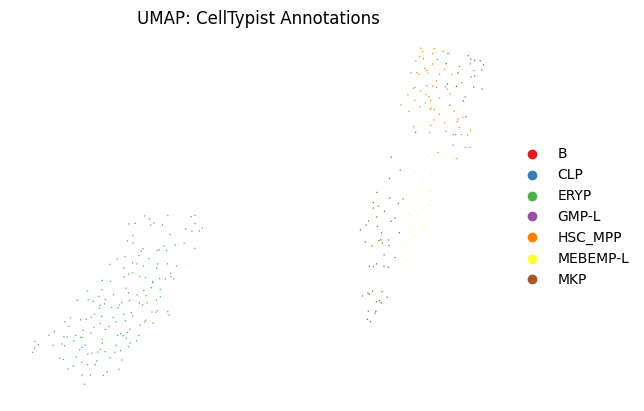

In [206]:
# Compute UMAP if not already done
if 'X_umap' not in adata_ct.obsm:
    sc.tl.umap(adata_ct)
custom_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                  '#ffff33', '#a65628', '#f781bf', '#999999']

# Plot UMAP with legend outside
sc.pl.umap(
    adata_ct,
    color='celltypist_majority',
    legend_loc='right margin',  # place legend outside
    title='UMAP: CellTypist Annotations',
    frameon=False,              # removes frame for cleaner view
    size=4,                     # adjust dot size
    palette= custom_colors
)

In [207]:
# Cross-tabulation of clusters vs CellTypist labels
pd.crosstab(
    adata_ct.obs['leiden_0.7'],
    adata_ct.obs['celltypist_majority']
)

celltypist_majority,B,CLP,ERYP,GMP-L,HSC_MPP,MEBEMP-L,MKP
leiden_0.7,,,,,,,
0,5,14,1,2,65,3,3
1,0,0,88,0,0,0,0
2,0,0,79,0,0,0,0
3,0,0,0,0,1,16,46


In [208]:
# Select relevant columns
student_csv = adata_ct.obs[['sample', 'sample_id', 'leiden_0.7', 'celltypist_majority']]

# Save
student_csv.to_csv("Annotated_Cells_UMAP.csv")

In [209]:
# Output directory for DEGs
output_dir = "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model3"
os.makedirs(output_dir, exist_ok=True)

In [210]:
# Define reference sample
reference_sample = "Normal"

In [211]:
# Volcano plot thresholds
padj_thresh = 0.05
logfc_thresh = 1

In [212]:
# List all unique cell types
cell_types = adata_ct.obs['celltypist_majority'].unique()
print("Cell types found:", cell_types)

Cell types found: ['MEBEMP-L', 'HSC_MPP', 'B', 'CLP', 'MKP', 'GMP-L', 'ERYP']
Categories (7, object): ['B', 'CLP', 'ERYP', 'GMP-L', 'HSC_MPP', 'MEBEMP-L', 'MKP']


In [213]:
# Loop through each cell type
for cell in cell_types:
    print(f"\nProcessing cell type: {cell}")

    # Subset AnnData for the specific cell type
    adata_cell = adata_ct[adata_ct.obs['celltypist_majority'] == cell].copy()

    # Check number of cells per sample
    sample_counts = adata_cell.obs['sample'].value_counts()
    print(sample_counts)

     # Skip if fewer than 2 groups present, or if either group is too small
    if sample_counts.shape[0] < 2:
        print(f"Skipping {cell}: only one sample group present, cannot run DE")
        continue

    if (sample_counts < 3).any():  # optional: minimum cell threshold per group
        print(f"Skipping {cell}: one or more groups has too few cells (<3)")
        continue

    # Differential expression analysis
    sc.tl.rank_genes_groups(
        adata_cell,
        groupby='sample',            # phenotype column
        reference=reference_sample,  # control as reference
        method='wilcoxon',           # statistical test
        layer='lognorm',             # use log-normalized data
        pts=True,                    # compute fraction of cells expressing each gene
        use_raw=False                # using processed layer
    )

    # Extract results into a DataFrame
    degs = sc.get.rank_genes_groups_df(adata_cell, group=None)

    # Apply thresholds for significance
    degs['Significant'] = 'Not Sig'
    degs.loc[
        (degs['pvals_adj'] <= padj_thresh) &
        ((degs['logfoldchanges'] >= logfc_thresh) | (degs['logfoldchanges'] <= -logfc_thresh)),
        'Significant'
    ] = 'Significant'

    # Create folder for this cell type
    safe_cell_name = cell.replace(" ", "_").replace("/", "-")
    cell_folder = os.path.join(output_dir, safe_cell_name)
    os.makedirs(cell_folder, exist_ok=True)

    # Save raw DEGs and significant DEGs separately
    degs.to_csv(os.path.join(cell_folder, f"{safe_cell_name}_all_DEGs.csv"), index=False)
    degs_sig.to_csv(os.path.join(cell_folder, f"{safe_cell_name}_significant_DEGs.csv"), index=False)
    ...
    plot_file = os.path.join(cell_folder, f"{safe_cell_name}_volcano.png")

    print(f"DEGs saved for {cell}: total={len(degs)}, significant={len(degs_sig)}")

    # -------------------------
    # Volcano plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=degs,
        x='logfoldchanges',
        y=-np.log10(degs['pvals_adj'] + 1e-300),  # avoid -inf
        hue='Significant',
        palette={'Not Sig':'gray', 'Significant':'red'},
        alpha=0.7
    )

    # Add threshold lines
    plt.axvline(x=logfc_thresh, color='blue', linestyle='--', lw=1)
    plt.axvline(x=-logfc_thresh, color='blue', linestyle='--', lw=1)
    plt.axhline(y=-np.log10(padj_thresh), color='green', linestyle='--', lw=1)

    plt.title(f"Volcano Plot: {cell}")
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted P-value")
    plt.legend(title='Significance')

    # Save volcano plot
    plot_file = os.path.join(cell_folder, f"{safe_cell_name}_volcano.png")
    plt.tight_layout()
    plt.savefig(plot_file, dpi=300)
    plt.close()

    print(f"Volcano plot saved for {safe_cell_name}")


Processing cell type: MEBEMP-L
sample
Normal      17
Leukemia     2
Name: count, dtype: int64
Skipping MEBEMP-L: one or more groups has too few cells (<3)

Processing cell type: HSC_MPP
sample
Normal      53
Leukemia    13
Name: count, dtype: int64
DEGs saved for HSC_MPP: total=36601, significant=0
Volcano plot saved for HSC_MPP

Processing cell type: B
sample
Normal    5
Name: count, dtype: int64
Skipping B: only one sample group present, cannot run DE

Processing cell type: CLP
sample
Normal    14
Name: count, dtype: int64
Skipping CLP: only one sample group present, cannot run DE

Processing cell type: MKP
sample
Leukemia    46
Normal       3
Name: count, dtype: int64
DEGs saved for MKP: total=36601, significant=0
Volcano plot saved for MKP

Processing cell type: GMP-L
sample
Normal    2
Name: count, dtype: int64
Skipping GMP-L: only one sample group present, cannot run DE

Processing cell type: ERYP
sample
Leukemia    165
Normal        3
Name: count, dtype: int64
DEGs saved for ER

In [216]:
import shutil

shutil.make_archive("DEG_outputs", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs")
shutil.make_archive("DEG_outputs_model2", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model2")
shutil.make_archive("DEG_outputs_model3", 'zip', "/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model3")

'/content/Project_scRNAseq/Project_scRNAseq/DEG_outputs_model3.zip'